# Sequence Prediction Analysis
Load trained forward and backward models, then visualise how each model predicts token-by-token from an initial token.

**Forward model**: predicts x_{t+1} given x_{0..t} — context grows rightward  
**Backward model**: predicts x_{t-1} given x_{t..T} — context grows leftward

In [10]:
%matplotlib inline
from IPython.display import display

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from OneHot_model import OneHotDecoder

print('Imports OK')

Imports OK


## Config — edit to match your trained model

In [11]:
# ── Architecture — must match training CFG ────────────────────────────────
D_MODEL    = 64
MAX_LEN    = 2000
N_LAYERS   = 2
NUM_TOKEN  = 3      # coin=3, flower n=6 m=4 → 10

# ── Experiment to load ───────────────────────────────────────────────────
RESULTS_DIR = 'results'
EXP_TAG     = 'exp1_coin_p03_q04'

FW_WEIGHTS  = f'{RESULTS_DIR}/models/{EXP_TAG}_fw.pt'
BW_WEIGHTS  = f'{RESULTS_DIR}/models/{EXP_TAG}_bw.pt'

# ── Generation settings ──────────────────────────────────────────────────
START_TOKEN = 1      # token the model starts from
GEN_LEN     = 2000    # number of steps to generate
N_RUNS      = 5     # independent generation runs to show variance

# token labels for coin process
TOKEN_LABELS = {0: '0 (T→T)', 1: '1 (→H)', 2: '2 (H→T)'}
# for flower: {i: f'die {i}' for i in range(n)} | {n+j: f'face {j}' for j in range(m)}

## Load Models

In [12]:
def load_model(path, mode):
    model = OneHotDecoder(
        token_size=NUM_TOKEN, d_model=D_MODEL,
        max_len=MAX_LEN, mode=mode, n_layers=N_LAYERS)
    model.load_state_dict(torch.load(path, map_location='cpu'))
    model.eval()
    print(f'  loaded {path}  [{mode}]')
    return model

model_fw = load_model(FW_WEIGHTS, 'forward')
model_bw = load_model(BW_WEIGHTS, 'backward')

  loaded results/models/exp1_coin_p03_q04_fw.pt  [forward]
  loaded results/models/exp1_coin_p03_q04_bw.pt  [backward]


## Core generation functions

In [13]:
def get_probs(model, context):
    """
    Run model on context and return the prediction probabilities.
    Forward : reads logits at last position  (max past context)
    Backward: reads logits at first position (max future context)
    """
    is_bw = (model.mode == 'backward')
    x = torch.tensor([context])           # (1, T)
    with torch.no_grad():
        logits = model(x)                 # (1, T, V)
    logits = logits[:, 0, :] if is_bw else logits[:, -1, :]  # (1, V)
    probs  = torch.softmax(logits[0], dim=-1).numpy()         # (V,)
    return probs


def generate_sequence(model, start_token, gen_len, burn_in=200):
    is_bw     = (model.mode == 'backward')
    context   = [start_token]
    sequence  = []
    prob_hist = []
    chosen    = []

    with torch.no_grad():
        for i in range(gen_len + burn_in):
            probs      = get_probs(model, context)
            next_token = int(np.random.choice(NUM_TOKEN, p=probs))

            # only record after burn-in
            if i >= burn_in:
                prob_hist.append(probs)
                chosen.append(next_token)
                sequence.append(next_token)

            if is_bw:
                context = [next_token] + context   # grow leftward
            else:
                context = context + [next_token]   # grow rightward

    # all three lists are now exactly gen_len long and aligned
    return sequence, prob_hist, chosen


print('Functions defined')

Functions defined


## 1 — Single generation trace
Show the full token sequence and the model's predicted distribution at each step.

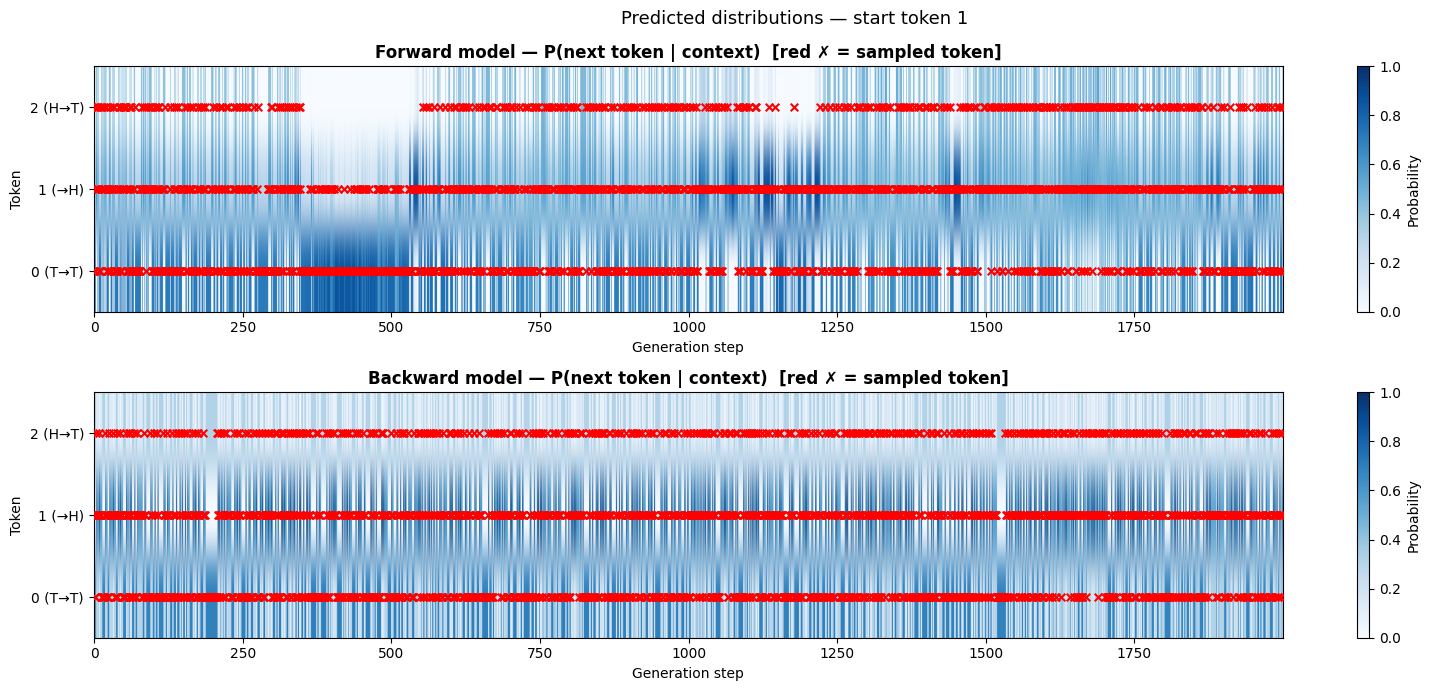

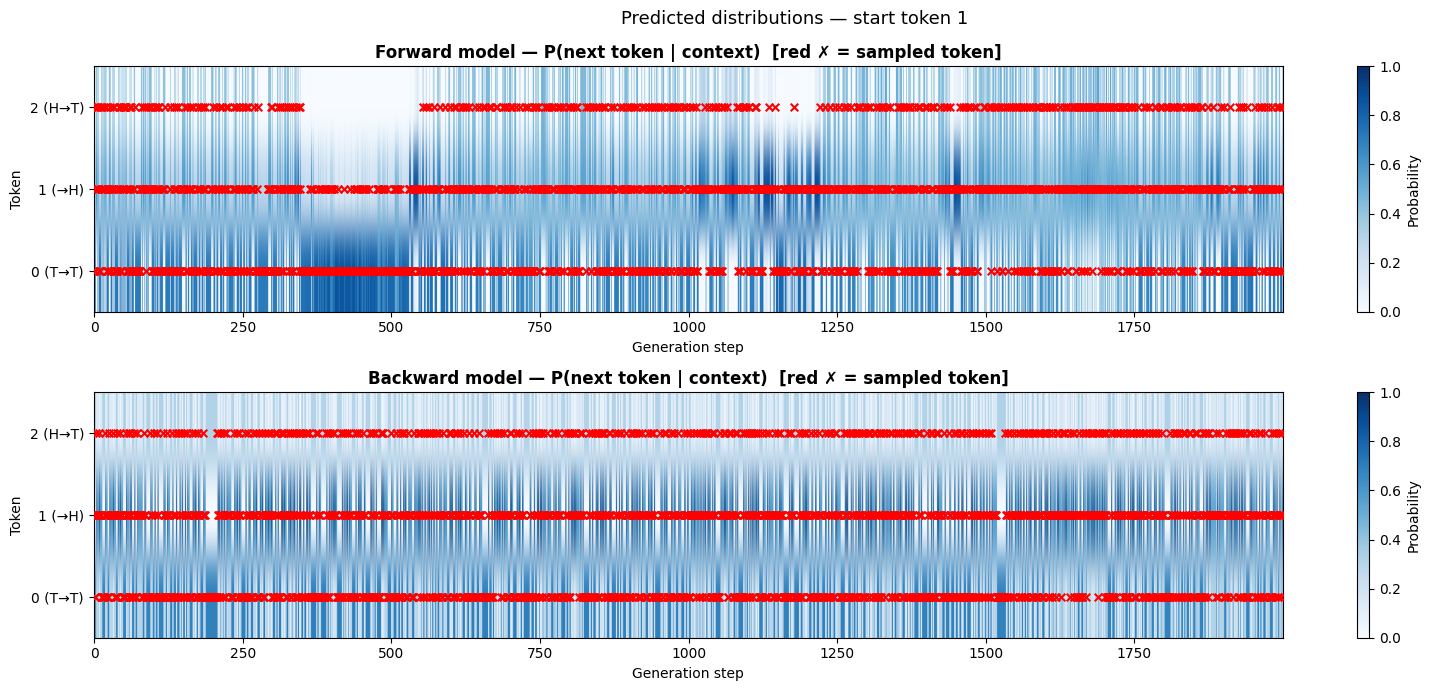

In [14]:
seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, GEN_LEN)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, GEN_LEN)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=False)

for ax, ph, ch, lbl in zip(axes, [ph_fw, ph_bw], [ch_fw, ch_bw],
                            ['Forward model', 'Backward model']):
    # heatmap of predicted probability distribution over steps
    mat = np.array(ph).T                          # (V, GEN_LEN)
    im  = ax.imshow(mat, aspect='auto', origin='lower',
                    cmap='Blues', vmin=0, vmax=1)
    # mark the chosen token at each step
    for t, tok in enumerate(ch):
        ax.scatter(t, tok, color='red', s=30, zorder=5, marker='x')
    ax.set_yticks(range(NUM_TOKEN))
    ax.set_yticklabels([TOKEN_LABELS.get(i, str(i)) for i in range(NUM_TOKEN)])
    ax.set_xlabel('Generation step')
    ax.set_ylabel('Token')
    ax.set_title(f'{lbl} — P(next token | context)  [red ✗ = sampled token]',
                 fontweight='bold')
    plt.colorbar(im, ax=ax, label='Probability')

plt.suptitle(f'Predicted distributions — start token {START_TOKEN}', fontsize=13)
plt.tight_layout()
display(fig)

## 2 — Generated token sequences (raw)
Print the actual token sequences produced by each model.

In [16]:
print(f'Start token: {START_TOKEN}')
print()
print(f'Forward  sequence ({GEN_LEN} tokens):')
print(' '.join(str(t) for t in seq_fw))
print()
print(f'Backward sequence ({GEN_LEN} tokens):')
print(' '.join(str(t) for t in seq_bw))
print()
# token frequency
for lbl, seq in [('Forward', seq_fw), ('Backward', seq_bw)]:
    counts = np.bincount(seq, minlength=NUM_TOKEN)
    freqs  = counts / len(seq)
    freq_str = '  '.join(f'tok{i}={freqs[i]:.3f}' for i in range(NUM_TOKEN))
    print(f'{lbl} token frequencies:  {freq_str}')

Start token: 1

Forward  sequence (2000 tokens):
2 0 1 1 1 2 1 2 0 0 0 1 2 1 2 1 1 2 1 1 2 0 0 0 1 1 1 2 0 0 1 1 2 1 2 0 0 0 0 0 1 1 2 0 1 2 0 1 2 1 2 1 2 1 2 0 0 0 0 1 2 1 2 0 0 0 1 1 2 0 0 0 0 0 0 0 0 0 1 1 2 1 1 1 2 1 1 2 0 1 2 1 1 1 1 1 2 0 0 0 0 1 2 0 1 2 0 1 2 1 2 0 0 0 0 1 1 1 1 2 0 0 0 0 0 0 0 1 2 0 0 0 0 0 1 2 1 2 0 0 1 2 0 0 0 0 0 1 1 1 1 1 1 2 0 1 1 2 0 1 1 1 2 0 0 1 2 0 0 0 0 0 0 1 1 2 0 0 1 1 2 0 0 1 2 1 1 2 0 0 0 0 0 0 0 0 1 1 1 1 2 0 0 1 1 2 0 0 1 1 1 2 0 0 0 1 2 0 1 1 1 1 2 0 1 2 0 0 0 0 0 0 0 0 1 2 1 1 1 2 0 0 0 1 2 0 0 0 1 1 2 0 0 1 1 2 0 1 1 2 0 0 0 0 1 1 1 1 1 2 0 0 0 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 2 0 1 2 0 0 0 0 0 0 1 1 2 0 1 1 2 0 1 2 0 0 1 1 1 2 1 1 1 1 2 0 1 2 0 1 2 0 0 1 1 1 1 2 1 1 1 2 0 1 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0

In [17]:
def theory_freq(p, q):
    token1 = p/(p+q)
    token0 = (1-p)*q/(p+q)
    token2 = p*q/(p+q)
    return token0, token1, token2
fre0 , freq1, freq2 = theory_freq(0.3, 0.4)
print(f"freq0: {fre0}, freq1: {freq1}, freq2: {freq2}")


freq0: 0.39999999999999997, freq1: 0.4285714285714286, freq2: 0.17142857142857143


## 3 — Predicted probability at each step (line plot)
Show how confident each model is as context grows.

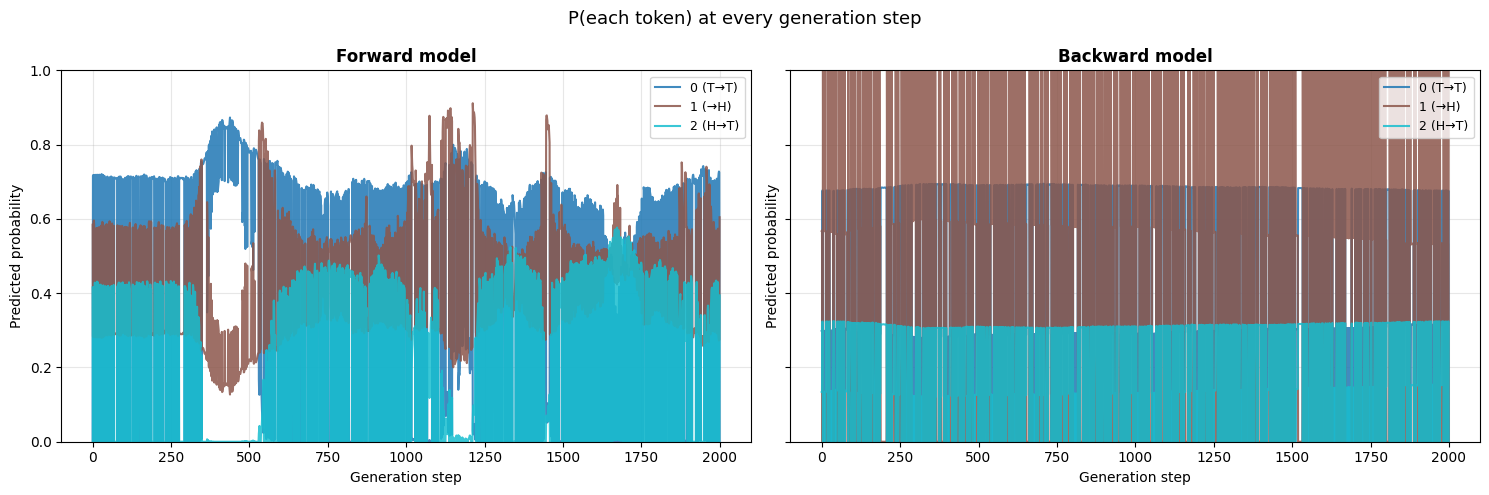

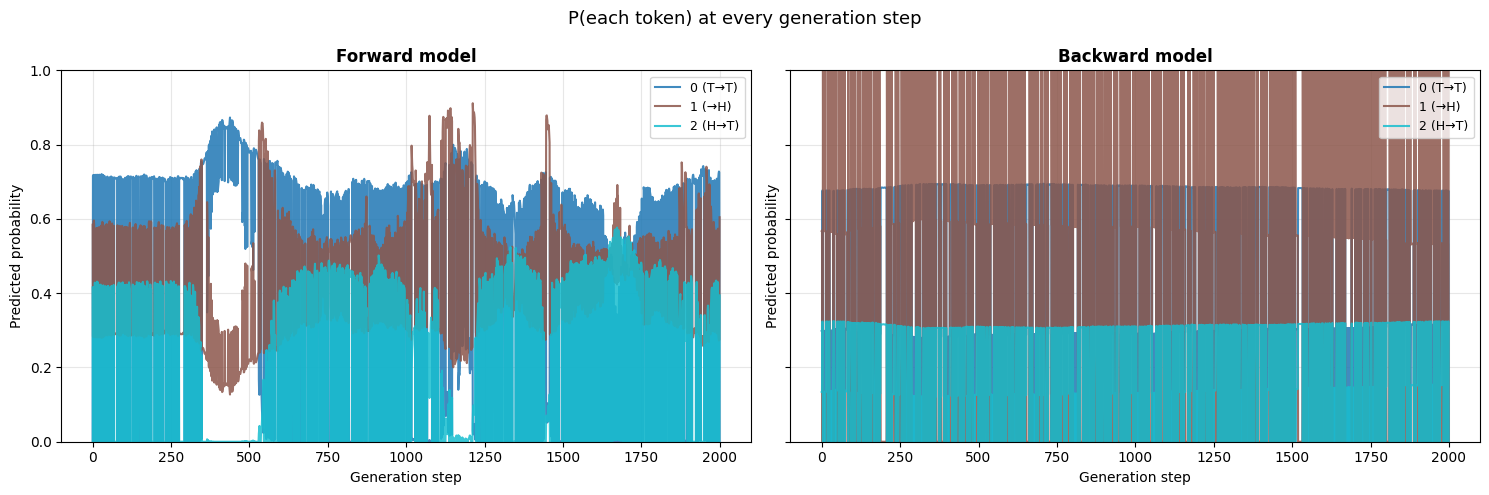

In [18]:
steps = np.arange(GEN_LEN)
cmap  = plt.cm.tab10

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, ph, lbl in zip(axes, [ph_fw, ph_bw],
                        ['Forward model', 'Backward model']):
    for tok in range(NUM_TOKEN):
        p_tok = [ph[t][tok] for t in range(GEN_LEN)]
        ax.plot(steps, p_tok, lw=1.5, alpha=0.85,
                c=cmap(tok / max(NUM_TOKEN - 1, 1)),
                label=TOKEN_LABELS.get(tok, f'Token {tok}'))
    ax.set_xlabel('Generation step')
    ax.set_ylabel('Predicted probability')
    ax.set_title(lbl, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('P(each token) at every generation step', fontsize=13)
plt.tight_layout()
display(fig)

## 4 — Multiple runs: variance across independent generations
Run N_RUNS independent sequences to show the model's stochasticity.

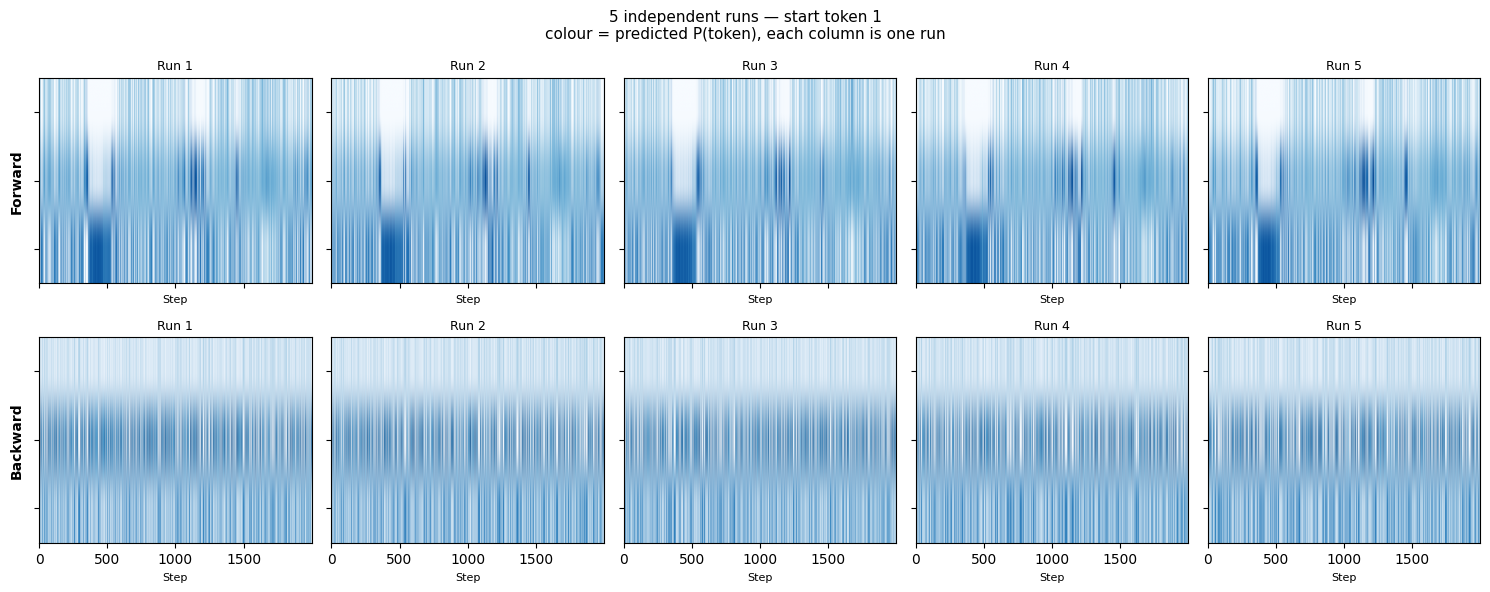

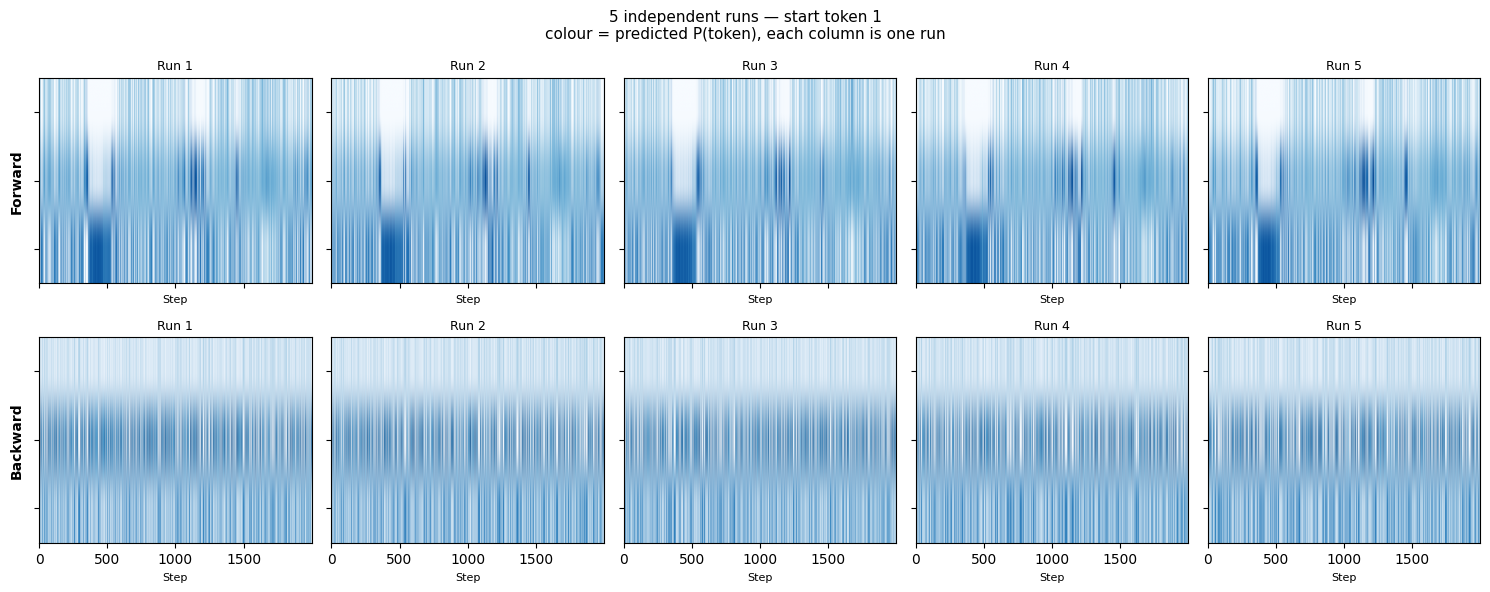

In [19]:
fig, axes = plt.subplots(2, N_RUNS, figsize=(3 * N_RUNS, 6),
                         sharey='row', sharex=True)

for row, (model, lbl) in enumerate([(model_fw, 'Forward'),
                                     (model_bw, 'Backward')]):
    for col in range(N_RUNS):
        _, ph, _ = generate_sequence(model, START_TOKEN, GEN_LEN)
        mat = np.array(ph).T
        ax  = axes[row][col]
        ax.imshow(mat, aspect='auto', origin='lower',
                  cmap='Blues', vmin=0, vmax=1)
        ax.set_yticks(range(NUM_TOKEN))
        if col == 0:
            ax.set_yticklabels(
                [TOKEN_LABELS.get(i, str(i)) for i in range(NUM_TOKEN)],
                fontsize=8)
            ax.set_ylabel(lbl, fontweight='bold')
        else:
            ax.set_yticklabels([])
        ax.set_title(f'Run {col+1}', fontsize=9)
        ax.set_xlabel('Step', fontsize=8)

plt.suptitle(f'{N_RUNS} independent runs — start token {START_TOKEN}\n'
             'colour = predicted P(token), each column is one run',
             fontsize=11)
plt.tight_layout()
display(fig)

## 5 — Step-by-step prediction table
Print exactly what the model predicts at each step so you can trace the logic.

In [20]:
N_SHOW = 20   # number of steps to print

seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, N_SHOW)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, N_SHOW)

def print_trace(lbl, seq, prob_hist, chosen):
    tok_header = '  '.join(f'P(tok{i})' for i in range(NUM_TOKEN))
    print(f'\n{"-"*70}')
    print(f'  {lbl}   (start={seq[0]})')
    print(f'  {"step":>4}  {"context":>8}  →  {"chosen":>6}  |  {tok_header}')
    print(f'{"-"*70}')
    context = [seq[0]]
    for t, (tok, probs) in enumerate(zip(chosen, prob_hist)):
        ctx_str  = str(context[-5:]).replace(' ', '')  # last 5 tokens of context
        prob_str = '  '.join(f'{p:>8.4f}' for p in probs)
        print(f'  {t:>4}  {ctx_str:>8}  →  {tok:>6}  |  {prob_str}')
        if model_fw.mode == 'forward':
            context.append(tok)
        else:
            context = [tok] + context

print_trace('FORWARD  model', seq_fw, ph_fw, ch_fw)
print_trace('BACKWARD model', seq_bw, ph_bw, ch_bw)


----------------------------------------------------------------------
  FORWARD  model   (start=0)
  step   context  →  chosen  |  P(tok0)  P(tok1)  P(tok2)
----------------------------------------------------------------------
     0       [0]  →       0  |    0.7120    0.2879    0.0001
     1     [0,0]  →       1  |    0.7155    0.2844    0.0001
     2   [0,0,1]  →       2  |    0.0001    0.5840    0.4159
     3  [0,0,1,2]  →       1  |    0.7185    0.2814    0.0001
     4  [0,0,1,2,1]  →       2  |    0.0001    0.5949    0.4050
     5  [0,1,2,1,2]  →       0  |    0.7175    0.2825    0.0001
     6  [1,2,1,2,0]  →       0  |    0.7173    0.2826    0.0001
     7  [2,1,2,0,0]  →       1  |    0.7161    0.2838    0.0001
     8  [1,2,0,0,1]  →       1  |    0.0001    0.5745    0.4254
     9  [2,0,0,1,1]  →       1  |    0.0001    0.5854    0.4145
    10  [0,0,1,1,1]  →       2  |    0.0001    0.5864    0.4135
    11  [0,1,1,1,2]  →       0  |    0.7169    0.2830    0.0001
    12  [1,1,

## 6 — Perplexity along the generated sequence
Plot rolling perplexity = 2^(-log2 P(chosen)) at each step.

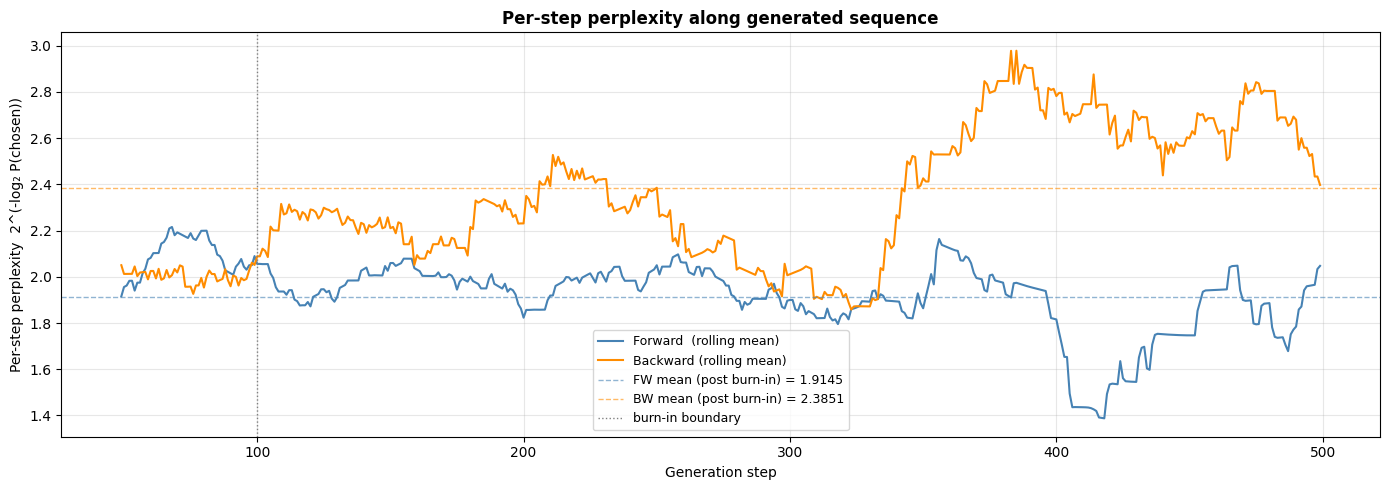


Final PPL estimate  (steps 100–500):
  Forward  PPL = 1.9145
  Backward PPL = 2.3851


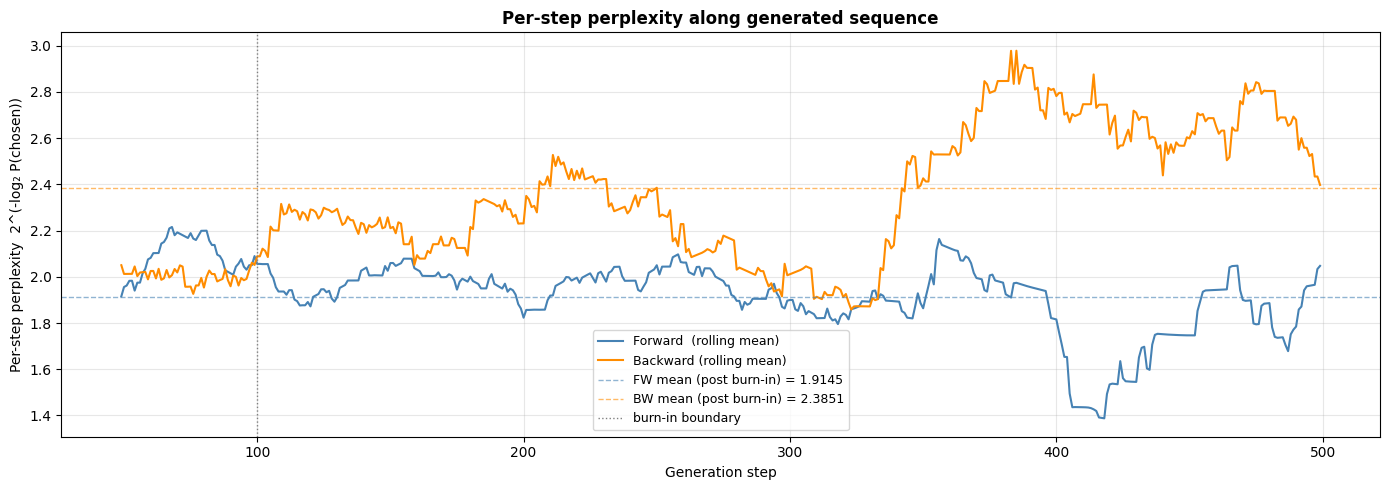

In [21]:
GEN_LEN_PPL = 500
WINDOW      = 50    # rolling window for smoothing

seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, GEN_LEN_PPL)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, GEN_LEN_PPL)

def step_ppl(prob_hist, chosen):
    """Per-step perplexity = 2^(-log2 P(chosen token))"""
    return [2 ** (-np.log2(prob_hist[t][tok] + 1e-12))
            for t, tok in enumerate(chosen)]

ppl_fw = step_ppl(ph_fw, ch_fw)
ppl_bw = step_ppl(ph_bw, ch_bw)

# rolling mean
roll_fw = np.convolve(ppl_fw, np.ones(WINDOW)/WINDOW, mode='valid')
roll_bw = np.convolve(ppl_bw, np.ones(WINDOW)/WINDOW, mode='valid')
steps_r = np.arange(WINDOW - 1, GEN_LEN_PPL)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps_r, roll_fw, color='steelblue',  lw=1.5, label='Forward  (rolling mean)')
ax.plot(steps_r, roll_bw, color='darkorange', lw=1.5, label='Backward (rolling mean)')

mean_fw = np.mean(ppl_fw[100:])   # after burn-in
mean_bw = np.mean(ppl_bw[100:])
ax.axhline(mean_fw, color='steelblue',  ls='--', lw=1, alpha=0.6,
           label=f'FW mean (post burn-in) = {mean_fw:.4f}')
ax.axhline(mean_bw, color='darkorange', ls='--', lw=1, alpha=0.6,
           label=f'BW mean (post burn-in) = {mean_bw:.4f}')
ax.axvline(100, color='grey', ls=':', lw=1, label='burn-in boundary')

ax.set_xlabel('Generation step')
ax.set_ylabel('Per-step perplexity  2^(-log₂ P(chosen))')
ax.set_title('Per-step perplexity along generated sequence', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)

print(f'\nFinal PPL estimate  (steps 100–{GEN_LEN_PPL}):')
print(f'  Forward  PPL = {mean_fw:.4f}')
print(f'  Backward PPL = {mean_bw:.4f}')

In [22]:
def cumulative_ppl(prob_hist, chosen):
    """
    Standard perplexity estimated from the beginning up to each step t:

        PPL_t = 2 ^ ( -1/t  Σ_{i=0}^{t}  log2 P(x_i | x_{<i}) )

    This is the standard formula applied to an expanding window [0..t].
    As t → ∞ on a stationary process it converges to 2^H∞.

    Returns
    -------
    ppl_curve : np.ndarray (N,) — one PPL estimate per step
    """
    log2_probs = np.array([
        -np.log2(prob_hist[t][tok] + 1e-12)
        for t, tok in enumerate(chosen)
    ])                                        # (N,) — per-step negative log2 prob

    # cumulative mean up to each t:  (1/t) * Σ_{i=0}^{t} log2_probs[i]
    cumulative_mean = np.cumsum(log2_probs) / np.arange(1, len(log2_probs) + 1)

    return 2 ** cumulative_mean              # (N,) — standard PPL up to step t

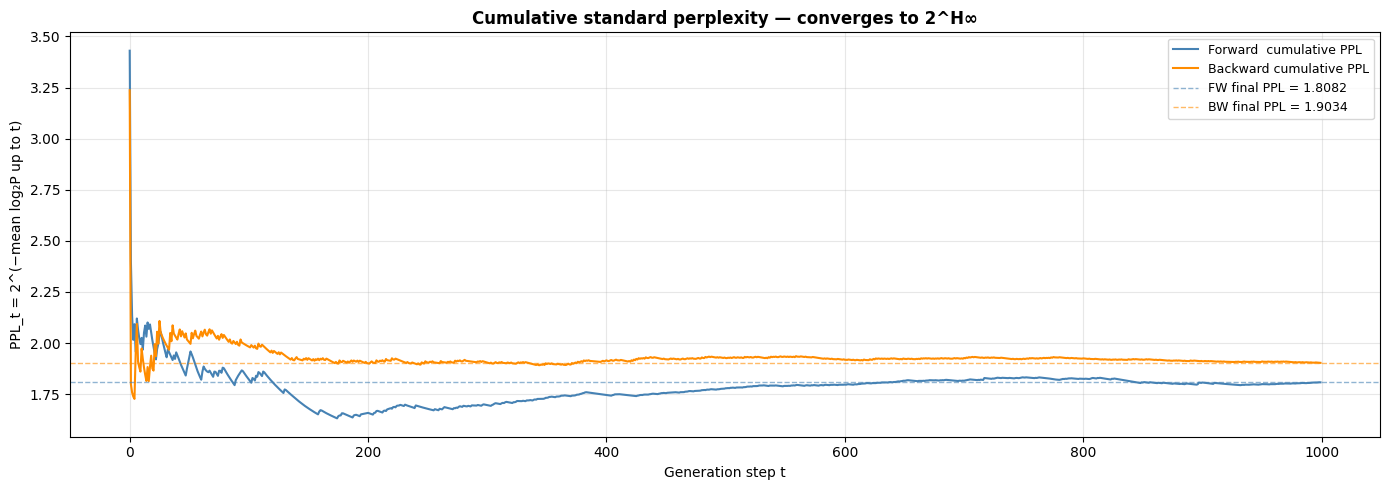


Final standard PPL at step 1000:
  Forward  PPL = 1.8082
  Backward PPL = 1.9034


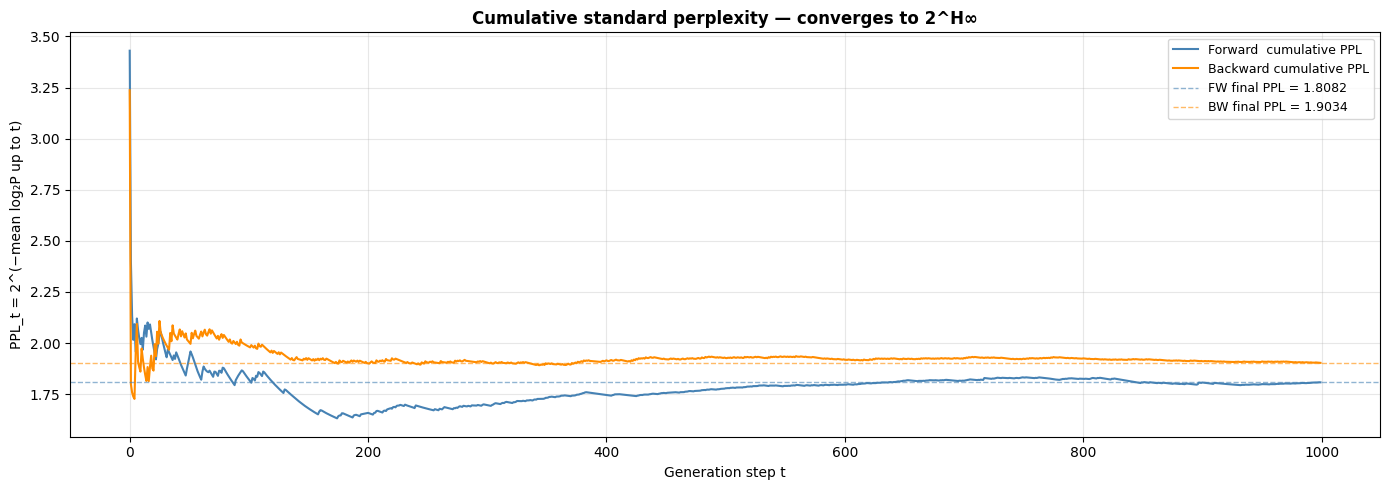

In [24]:
GEN_LEN_PPL = 1000
BURN_IN     = 500

seq_fw, ph_fw, ch_fw = generate_sequence(model_fw, START_TOKEN, GEN_LEN_PPL, burn_in=BURN_IN)
seq_bw, ph_bw, ch_bw = generate_sequence(model_bw, START_TOKEN, GEN_LEN_PPL, burn_in=BURN_IN)

ppl_curve_fw = cumulative_ppl(ph_fw, ch_fw)
ppl_curve_bw = cumulative_ppl(ph_bw, ch_bw)
steps = np.arange(len(ppl_curve_fw))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(steps, ppl_curve_fw, color='steelblue',  lw=1.5, label='Forward  cumulative PPL')
ax.plot(steps, ppl_curve_bw, color='darkorange', lw=1.5, label='Backward cumulative PPL')

final_fw = ppl_curve_fw[-1]
final_bw = ppl_curve_bw[-1]
ax.axhline(final_fw, color='steelblue',  ls='--', lw=1, alpha=0.6,
           label=f'FW final PPL = {final_fw:.4f}')
ax.axhline(final_bw, color='darkorange', ls='--', lw=1, alpha=0.6,
           label=f'BW final PPL = {final_bw:.4f}')

ax.set_xlabel('Generation step t')
ax.set_ylabel('PPL_t = 2^(−mean log₂P up to t)')
ax.set_title('Cumulative standard perplexity — converges to 2^H∞', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
display(fig)

print(f'\nFinal standard PPL at step {GEN_LEN_PPL}:')
print(f'  Forward  PPL = {final_fw:.4f}')
print(f'  Backward PPL = {final_bw:.4f}')